# Distribuciones de probabilidad, censura y crítica de modelos en análisis de vida

### Un cuaderno para ingeniería de confiabilidad

**Tesis del documento.** Los datos no "siguen" una distribución. Un modelo estadístico es
una descripción aproximada que nosotros proponemos y que debe ganarse su lugar frente a la
evidencia. Como escribió Box, dado que todos los modelos son falsos, el científico debe estar
alerta a *en qué* son importantemente falsos ([Box, 1976, p. 792](https://doi.org/10.1080/01621459.1976.10480949)).

---

### Qué cubre

| Parte | Contenido | Pregunta que responde |
|---|---|---|
| **1** | Distribuciones de vida: $f$, $F$, $R$, $h$; exponencial, Weibull, lognormal, gamma | ¿Qué describe cada modelo y cómo se ve? |
| **2** | Media, mediana, varianza: asimetría, valores extremos, momentos que no existen | ¿Qué resumen reportar y cuándo el promedio engaña? |
| **3** | Censura: tipos, Kaplan–Meier, máxima verosimilitud, censura informativa | ¿Qué hacer con las unidades que no fallaron? |
| **4** | Los modelos siguen a los datos, no al revés | ¿Cuándo *no* debo creerle a mi ajuste? |

### Cómo usarlo

Ejecute las celdas en orden. Todo el código es autocontenido (`numpy`, `scipy`, `pandas`,
`matplotlib`) y los estimadores centrales —Kaplan–Meier, varianza de Greenwood, verosimilitud
Weibull con censura— están **implementados a mano**, no invocados de una librería, para que
cada supuesto quede visible.

> **Advertencia de trazabilidad.** Todos los datos de este cuaderno son **simulados**, generados
> con parámetros conocidos que se declaran en cada celda. Esto es deliberado: solo conociendo la
> verdad podemos medir cuánto se equivoca cada método. Ningún número proviene de un activo real
> ni de una organización identificable. Las fuentes citadas respaldan los **métodos**, no los
> resultados numéricos de los ejemplos.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize

RNG = np.random.default_rng(20260912)   # semilla fija: resultados reproducibles

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
C = {"exp": "#2683C6", "wei": "#E67B2E", "log": "#3E8853",
     "gam": "#9B59B6", "ref": "#646A6E", "bad": "#C00000"}

pd.set_option("display.width", 120)
print("numpy", np.__version__, "| scipy", __import__("scipy").__version__)

numpy 2.4.6 | scipy 1.17.1


---
# Parte 1 · Distribuciones de probabilidad en tiempos de vida

## 1.1 Las cuatro funciones son la misma información

Sea $T \ge 0$ el tiempo hasta la falla. Toda la descripción probabilística cabe en cuatro
funciones **matemáticamente equivalentes**: conocer una implica conocer las otras tres.

| Función | Definición | Lectura de ingeniería |
|---|---|---|
| Densidad | $$f(t)$$ | Dónde se concentran las fallas |
| Acumulada | $$F(t)=P(T\le t)=\int_0^t f(u)\,du$$ | Probabilidad de haber fallado antes de $t$ |
| Confiabilidad | $$R(t)=1-F(t)=P(T>t)$$ | Probabilidad de sobrevivir más allá de $t$ |
| Tasa de riesgo | $$h(t)=\dfrac{f(t)}{R(t)}$$ | Riesgo **instantáneo condicionado a haber llegado vivo** a $t$ |

Las relaciones fundamentales son:

$$h(t)=-\frac{d}{dt}\ln R(t), \qquad R(t)=\exp\!\left(-\int_0^t h(u)\,du\right)=e^{-H(t)}$$

**$h(t)$ es la función que más importa en confiabilidad**, porque es la única que se interpreta
condicionalmente: describe el riesgo del equipo *que ya sobrevivió hasta hoy*, que es
exactamente la población sobre la que se decide mantener, intervenir o reemplazar. Las otras
tres miran hacia atrás, desde el origen.

Una advertencia de vocabulario: $h(t)$ **no es una probabilidad**. Tiene unidades de
$1/\text{tiempo}$ y puede exceder 1. La probabilidad es $h(t)\,\Delta t$ para $\Delta t$ pequeño.

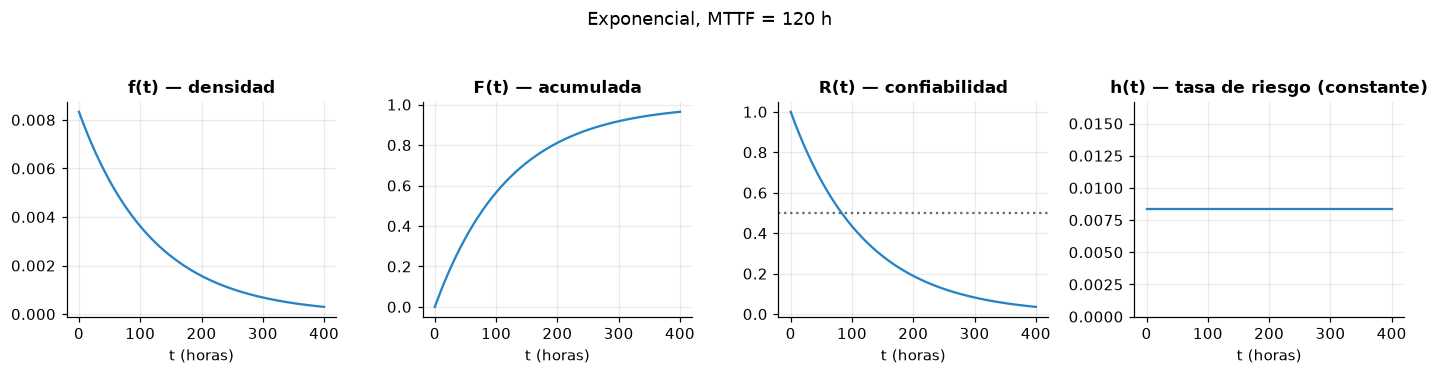

R(MTTF) = R(120) = 0.3679
  -> En CUALQUIER exponencial, solo el 36,8 % sobrevive hasta su propia media.
Mediana = 83.2 h  <  Media = 120,0 h


In [2]:
# Exponencial con MTTF = 120 h: las cuatro vistas de la misma información
t = np.linspace(0.01, 400, 800)
lam = 1 / 120.0

fig, ax = plt.subplots(1, 4, figsize=(13, 3.2))
ax[0].plot(t, lam * np.exp(-lam * t), color=C["exp"]); ax[0].set_title("f(t) — densidad")
ax[1].plot(t, 1 - np.exp(-lam * t), color=C["exp"]); ax[1].set_title("F(t) — acumulada")
ax[2].plot(t, np.exp(-lam * t), color=C["exp"]); ax[2].set_title("R(t) — confiabilidad")
ax[2].axhline(.5, ls=":", color=C["ref"])
ax[3].plot(t, np.full_like(t, lam), color=C["exp"]); ax[3].set_ylim(0, 2 * lam)
ax[3].set_title("h(t) — tasa de riesgo (constante)")
for a in ax:
    a.set_xlabel("t (horas)")
fig.suptitle("Exponencial, MTTF = 120 h", y=1.05)
fig.tight_layout(); plt.show()

print(f"R(MTTF) = R(120) = {np.exp(-1):.4f}")
print("  -> En CUALQUIER exponencial, solo el 36,8 % sobrevive hasta su propia media.")
print(f"Mediana = {120*np.log(2):.1f} h  <  Media = 120,0 h")

Ese primer resultado ya desmonta una intuición peligrosa: **el MTTF no es un tiempo típico ni
un punto de corte prudente**. En una exponencial, el 63,2 % de las unidades ya falló al llegar a
la media. Si alguien programa un reemplazo "al MTTF", está aceptando que dos de cada tres
unidades fallen antes.

## 1.2 Exponencial: tasa constante y falta de memoria

$$f(t)=\lambda e^{-\lambda t},\qquad R(t)=e^{-\lambda t},\qquad h(t)=\lambda,\qquad
E[T]=\frac{1}{\lambda},\qquad \text{Mediana}=\frac{\ln 2}{\lambda}\approx 0{,}693\,E[T]$$

La exponencial es la **única** distribución continua sin memoria:

$$P(T>s+t \mid T>s) = P(T>t)\quad \text{para todo } s,t\ge 0$$

Un equipo con vida exponencial que lleva 10.000 horas operando es estadísticamente idéntico a
uno nuevo. Esto es un supuesto físico muy fuerte, no una conveniencia matemática: implica que
**no hay desgaste, no hay envejecimiento y no hay rodaje**. Es el supuesto que subyace al
estimador $\widehat{\text{MTBF}} = T/r$ bajo un proceso de Poisson homogéneo
([NIST/SEMATECH, 2012](https://doi.org/10.18434/M32189)).

Verifiquemos la propiedad por simulación y veamos que **deja de cumplirse** en cuanto la tasa
de riesgo no es constante.

In [3]:
n = 200_000

# --- Exponencial: la condición no cambia nada
x = RNG.exponential(120, n)
print("EXPONENCIAL (sin memoria)")
print(f"  P(T > 50)            = {(x > 50).mean():.4f}")
print(f"  P(T > 150 | T > 100) = {(x[x > 100] > 150).mean():.4f}   <- iguales")

# --- Weibull con desgaste: sobrevivir CUESTA cada vez más
y = stats.weibull_min.rvs(2.5, scale=135.4, size=n, random_state=RNG)
print("\nWEIBULL beta = 2,5 (desgaste)")
print(f"  P(T > 50)            = {(y > 50).mean():.4f}")
print(f"  P(T > 150 | T > 100) = {(y[y > 100] > 150).mean():.4f}   <- MUY distintas")
print("\n  El equipo usado NO es como nuevo: 50 h adicionales son mucho menos probables.")

EXPONENCIAL (sin memoria)
  P(T > 50)            = 0.6592
  P(T > 150 | T > 100) = 0.6609   <- iguales

WEIBULL beta = 2,5 (desgaste)
  P(T > 50)            = 0.9196
  P(T > 150 | T > 100) = 0.4376   <- MUY distintas

  El equipo usado NO es como nuevo: 50 h adicionales son mucho menos probables.


## 1.3 Weibull: un parámetro que codifica el mecanismo de falla

$$F(t)=1-e^{-(t/\eta)^{\beta}},\qquad h(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1},
\qquad E[T]=\eta\,\Gamma\!\left(1+\tfrac{1}{\beta}\right)$$

Con $\eta$ = vida característica (siempre $R(\eta)=e^{-1}=0{,}368$, para cualquier $\beta$) y
$\beta$ = parámetro de forma. El valor de $\beta$ **es una hipótesis sobre el mecanismo físico**:

| $\beta$ | $h(t)$ | Interpretación | Acción típica |
|---|---|---|---|
| $<1$ | decreciente | Mortalidad infantil: defectos de fabricación, montaje, puesta en marcha | Rodaje, control de calidad, revisar instalación |
| $=1$ | constante | Fallas aleatorias (se reduce a la exponencial) | El reemplazo preventivo por edad **no sirve** |
| $>1$ | creciente | Desgaste, fatiga, erosión, corrosión | El reemplazo por edad puede ser rentable |

Weibull (1951) propuso esta función explícitamente por razones **empíricas**, no teóricas.
Ante la objeción de que su distribución carecía de fundamento teórico, respondió que la única
vía de avance es escoger una función simple, ponerla a prueba y mantenerla mientras no aparezca
una mejor ([Weibull, 1951, p. 293](https://doi.org/10.1115/1.4010337)). Vale la pena retener
esa honestidad: el modelo más usado en confiabilidad nació declarándose una aproximación útil.

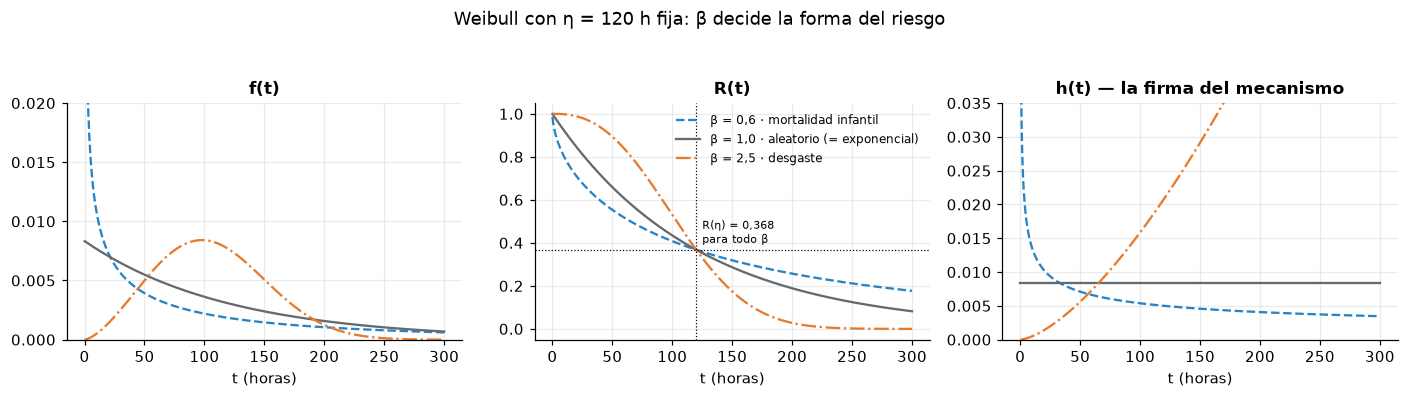

Misma vida característica η = 120 h, consecuencias operativas opuestas:

  β=0.6: media=  180.5 h | mediana=  65.1 h | CV=1.76 | B10=   2.8 h
  β=1.0: media=  120.0 h | mediana=  83.2 h | CV=1.00 | B10=  12.6 h
  β=2.5: media=  106.5 h | mediana= 103.6 h | CV=0.43 | B10=  48.8 h

  B10 = tiempo en que ha fallado el 10 %. Va de 2,8 h a 48,8 h: 17 veces.
  Reportar solo 'η = 120 h' oculta por completo esa diferencia.


In [4]:
t = np.linspace(0.1, 300, 600)
eta = 120.0
formas = [(0.6, "β = 0,6 · mortalidad infantil", "--", C["exp"]),
          (1.0, "β = 1,0 · aleatorio (= exponencial)", "-", C["ref"]),
          (2.5, "β = 2,5 · desgaste", "-.", C["wei"])]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for beta, lab, ls, col in formas:
    ax[0].plot(t, stats.weibull_min.pdf(t, beta, scale=eta), ls=ls, color=col, label=lab)
    ax[1].plot(t, stats.weibull_min.sf(t, beta, scale=eta), ls=ls, color=col, label=lab)
    ax[2].plot(t, (beta / eta) * (t / eta) ** (beta - 1), ls=ls, color=col, label=lab)
ax[0].set_title("f(t)"); ax[0].set_ylim(0, .02)
ax[1].set_title("R(t)"); ax[1].axhline(np.exp(-1), ls=":", color="k", lw=.8)
ax[1].axvline(eta, ls=":", color="k", lw=.8)
ax[1].text(125, .40, "R(η) = 0,368\npara todo β", fontsize=7.5)
ax[2].set_title("h(t) — la firma del mecanismo"); ax[2].set_ylim(0, .035)
for a in ax:
    a.set_xlabel("t (horas)")
ax[1].legend(fontsize=8, loc="upper right")
fig.suptitle("Weibull con η = 120 h fija: β decide la forma del riesgo", y=1.05)
fig.tight_layout(); plt.show()

print("Misma vida característica η = 120 h, consecuencias operativas opuestas:\n")
for beta, lab, _, _ in formas:
    d = stats.weibull_min(beta, scale=eta)
    print(f"  β={beta}: media={d.mean():7.1f} h | mediana={d.median():6.1f} h | "
          f"CV={d.std()/d.mean():.2f} | B10={d.ppf(.10):6.1f} h")
print("\n  B10 = tiempo en que ha fallado el 10 %. Va de 2,8 h a 48,8 h: 17 veces.")
print("  Reportar solo 'η = 120 h' oculta por completo esa diferencia.")

## 1.4 La curva de bañera no es una distribución

Un error frecuente es buscar "la distribución con forma de bañera". La curva de bañera no es un
modelo: es el resultado de **superponer mecanismos que compiten**. Si actúan simultáneamente
tres modos independientes, los riesgos se suman:

$$h_{\text{total}}(t)=h_{1}(t)+h_{2}(t)+h_{3}(t)$$

Esto tiene una consecuencia práctica de fondo: **ajustar una sola Weibull a una población con
varios mecanismos activos produce un $\beta$ promedio que no describe a ninguno de ellos**. La
respuesta correcta no es un modelo más flexible, sino segmentar los datos por modo de falla
—que es precisamente para lo que sirve la taxonomía de [ISO 14224:2016](https://www.iso.org/standard/64076.html).

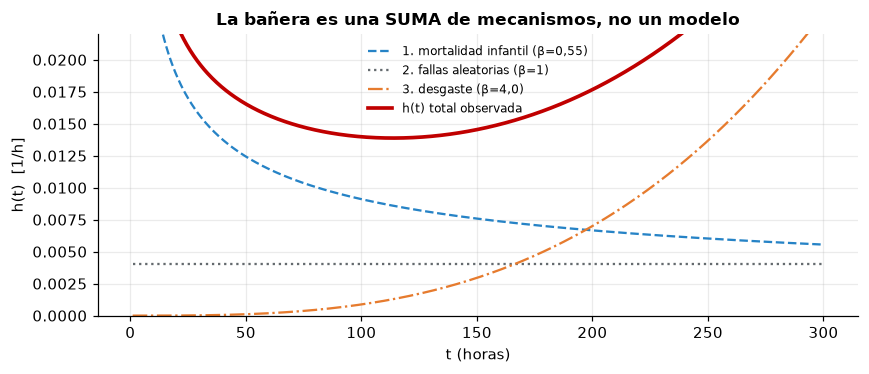

Si usted solo observa la curva roja y ajusta UNA Weibull,
obtendrá un β intermedio que no corresponde a ningún mecanismo real.


In [13]:
t = np.linspace(1, 300, 600)
h_inf  = (0.55 / 40) * (t / 40) ** (0.55 - 1)      # defectos de montaje
h_alea = np.full_like(t, 0.004)                     # eventos externos
h_desg = (4.0 / 260) * (t / 260) ** (4.0 - 1)       # fatiga

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t, h_inf,  ls="--", color=C["exp"], label="1. mortalidad infantil (β=0,55)")
ax.plot(t, h_alea, ls=":",  color=C["ref"], label="2. fallas aleatorias (β=1)")
ax.plot(t, h_desg, ls="-.", color=C["wei"], label="3. desgaste (β=4,0)")
ax.plot(t, h_inf + h_alea + h_desg, lw=2.4, color=C["bad"], label="h(t) total observada")
ax.set_ylim(0, .022); ax.set_xlabel("t (horas)"); ax.set_ylabel("h(t)  [1/h]")
ax.set_title("La bañera es una SUMA de mecanismos, no un modelo")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print("Si usted solo observa la curva roja y ajusta UNA Weibull,")
print("obtendrá un β intermedio que no corresponde a ningún mecanismo real.")

## 1.5 Comparación: cuatro modelos con vida parecida, colas muy distintas

- **Exponencial** — tasa constante. Único caso sin memoria. $CV = 1$ siempre.
- **Weibull** — flexible en la forma del riesgo. Mínimo de variables aleatorias
  (eslabón más débil): por eso modela bien fallas donde el defecto más severo domina.
- **Lognormal** — $\ln T$ es normal. Aparece cuando el daño se acumula de forma
  multiplicativa (propagación de grieta, corrosión) y es el modelo habitual para **tiempos de
  reparación**, porque captura la asimetría de unas pocas reparaciones muy largas.
- **Gamma** — suma de $k$ etapas exponenciales. Útil cuando la falla requiere que ocurran
  varios choques sucesivos.

,Media,Mediana,DE,CV,Asimetría,B10,P90
Modelo,,,,,,,
Exponencial (λ=1/120),120.00,83.18,120.00,1.00,2.00,12.64,276.31
"Weibull (β=2,5; η=135)",120.14,116.94,51.41,0.43,0.36,55.04,189.02
"Lognormal (μ=4,6; σ=0,8)",137.00,99.48,129.72,0.95,3.69,35.69,277.34
Gamma (k=3; θ=40),120.00,106.96,69.28,0.58,1.15,44.08,212.89


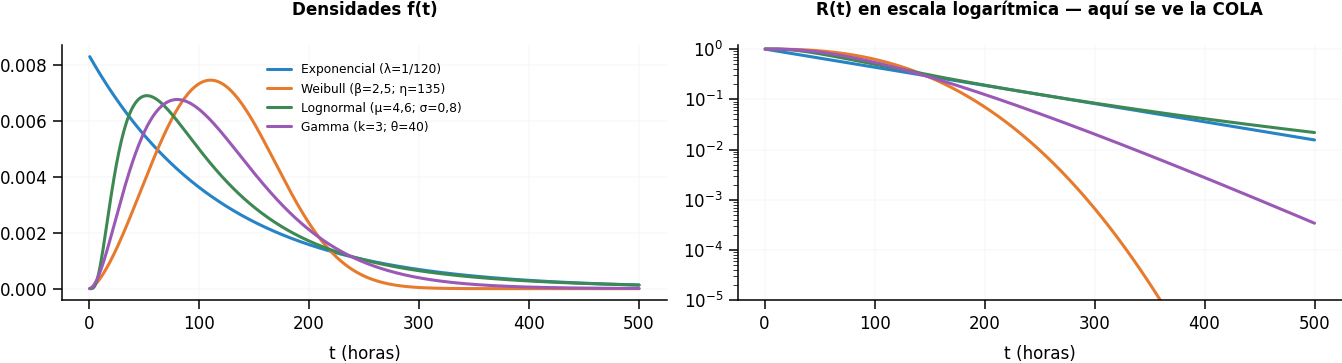

Medias casi idénticas (120–137 h), pero el B10 va de 12,6 h a 55,0 h.
En el panel logarítmico las curvas se separan varios órdenes de magnitud:
ahí es donde viven las decisiones de garantía, repuestos y riesgo.


In [6]:
modelos = {
    "Exponencial (λ=1/120)":     stats.expon(scale=120),
    "Weibull (β=2,5; η=135)":    stats.weibull_min(2.5, scale=135.4),
    "Lognormal (μ=4,6; σ=0,8)":  stats.lognorm(0.8, scale=np.exp(4.6)),
    "Gamma (k=3; θ=40)":         stats.gamma(3, scale=40),
}
tab = pd.DataFrame([{
    "Modelo": nom, "Media": d.mean(), "Mediana": d.median(), "DE": d.std(),
    "CV": d.std() / d.mean(), "Asimetría": float(d.stats("s")),
    "B10": d.ppf(.10), "P90": d.ppf(.90),
} for nom, d in modelos.items()]).set_index("Modelo").round(2)
display(tab)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))
tt = np.linspace(.5, 500, 700)
for (nom, d), c in zip(modelos.items(), [C["exp"], C["wei"], C["log"], C["gam"]]):
    ax[0].plot(tt, d.pdf(tt), color=c, label=nom)
    ax[1].semilogy(tt, d.sf(tt), color=c, label=nom)
ax[0].set_title("Densidades f(t)"); ax[0].legend(fontsize=8)
ax[1].set_title("R(t) en escala logarítmica — aquí se ve la COLA")
ax[1].set_ylim(1e-5, 1.2)
for a in ax:
    a.set_xlabel("t (horas)")
fig.tight_layout(); plt.show()

print("Medias casi idénticas (120–137 h), pero el B10 va de 12,6 h a 55,0 h.")
print("En el panel logarítmico las curvas se separan varios órdenes de magnitud:")
print("ahí es donde viven las decisiones de garantía, repuestos y riesgo.")

---
# Parte 2 · Media, mediana y varianza: qué resumen decide bien

## 2.1 En distribuciones asimétricas, la media no es el "centro"

Los tiempos de vida y de reparación son casi siempre **asimétricos a la derecha**: acotados
inferiormente por cero y sin límite superior. En ese régimen se cumple sistemáticamente

$$\text{moda} < \text{mediana} < \text{media}$$

y la media puede quedar en un percentil sorprendentemente alto. La media es el **centro de
masa** —el punto de equilibrio del histograma—, no el valor típico. Una sola reparación muy
larga la desplaza.

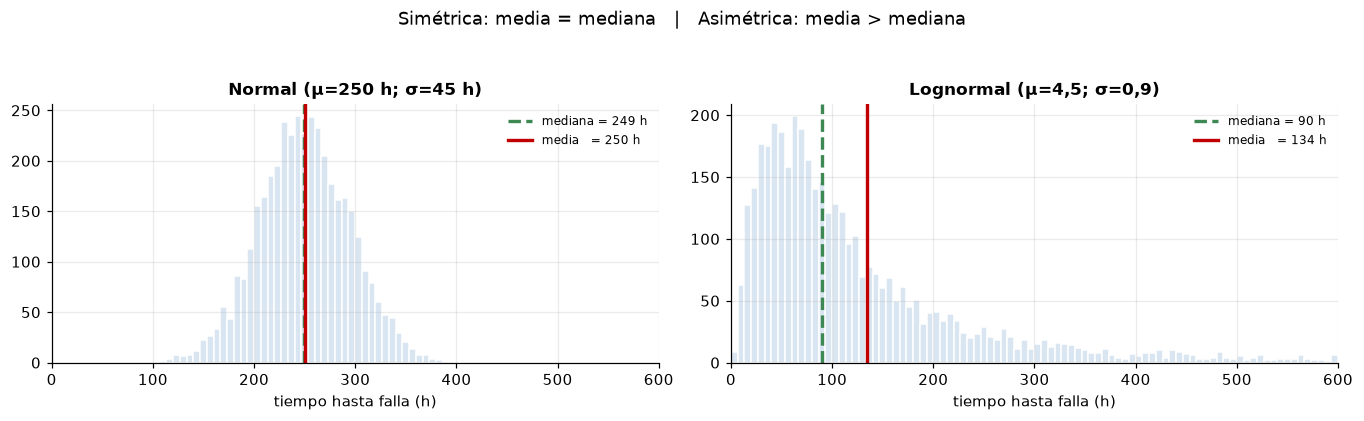

NORMAL     media= 250.0 h  mediana= 250.0 h  asimetría=0.00  P(T<media)=0.500
LOGNORMAL  media= 135.0 h  mediana=  90.0 h  asimetría=4.75  P(T<media)=0.674

Masa de probabilidad en t < 0 bajo la normal: 1.38e-08  (despreciable)


In [10]:
# ---- NORMAL con parámetros propios de un tiempo de vida por desgaste
d_n = stats.norm(loc=250, scale=45)          # loc = media (h); scale = desviación (h)
x_n = d_n.rvs(4000, random_state=RNG)

# ---- LOGNORMAL de contraste
d_l = stats.lognorm(0.9, scale=np.exp(4.5))
x_l = d_l.rvs(4000, random_state=RNG)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))
for a, x, nom in [(ax[0], x_n, "Normal (μ=250 h; σ=45 h)"),
                  (ax[1], x_l, "Lognormal (μ=4,5; σ=0,9)")]:
    a.hist(x, bins=90, range=(0, 600), color="#D9E6F2", edgecolor="white")
    a.axvline(np.median(x), color=C["log"], lw=2.2, ls="--",
              label=f"mediana = {np.median(x):.0f} h")
    a.axvline(x.mean(), color=C["bad"], lw=2.2,
              label=f"media   = {x.mean():.0f} h")
    a.set_xlim(0, 600); a.set_xlabel("tiempo hasta falla (h)")
    a.set_title(nom); a.legend(fontsize=8)
fig.suptitle("Simétrica: media = mediana   |   Asimétrica: media > mediana", y=1.05)
fig.tight_layout(); plt.show()

print(f"NORMAL     media={d_n.mean():6.1f} h  mediana={d_n.median():6.1f} h  "
      f"asimetría={float(d_n.stats('s')):.2f}  P(T<media)={d_n.cdf(d_n.mean()):.3f}")
print(f"LOGNORMAL  media={d_l.mean():6.1f} h  mediana={d_l.median():6.1f} h  "
      f"asimetría={float(d_l.stats('s')):.2f}  P(T<media)={d_l.cdf(d_l.mean()):.3f}")
print(f"\nMasa de probabilidad en t < 0 bajo la normal: {d_n.cdf(0):.2e}  (despreciable)")

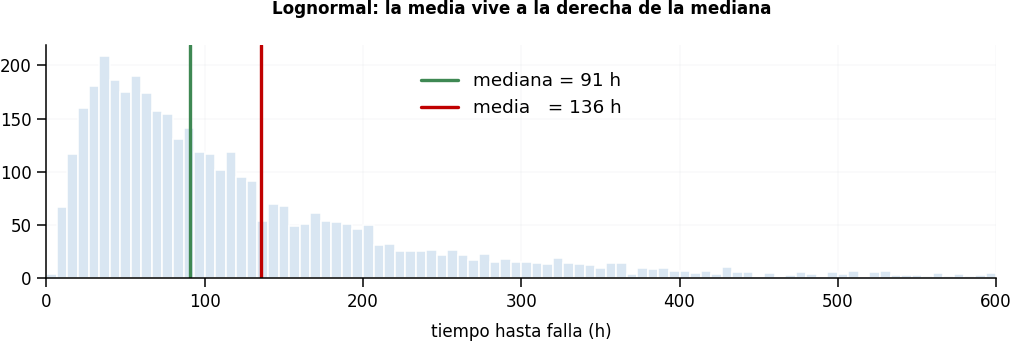

P(T < media) = 0.674
  -> El 67 % de las unidades falla ANTES de la media. La media no parte la población.


In [7]:
d = stats.lognorm(0.9, scale=np.exp(4.5))
x = d.rvs(4000, random_state=RNG)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.hist(x, bins=90, range=(0, 600), color="#D9E6F2", edgecolor="white")
ax.axvline(np.median(x), color=C["log"], lw=2.2, label=f"mediana = {np.median(x):.0f} h")
ax.axvline(x.mean(),     color=C["bad"], lw=2.2, label=f"media   = {x.mean():.0f} h")
ax.set_xlim(0, 600); ax.set_xlabel("tiempo hasta falla (h)")
ax.set_title("Lognormal: la media vive a la derecha de la mediana")
ax.legend(); fig.tight_layout(); plt.show()

print(f"P(T < media) = {d.cdf(d.mean()):.3f}")
print("  -> El 67 % de las unidades falla ANTES de la media. La media no parte la población.")

## 2.2 La varianza y la media son frágiles ante un solo valor extremo

La media y la desviación estándar tienen **punto de ruptura cero**: basta una observación
arbitrariamente grande para arrastrarlas a cualquier valor. La mediana tiene punto de ruptura
50 %. Esto no significa que la media sea "mala": significa que **reportar media sin mediana, sin
$n$ y sin dispersión oculta información que el lector necesita**.

In [8]:
base = np.array([1.0, 0.5, 1.5, 2.0, 1.2, 0.8, 1.1, 1.4])   # reparaciones rutinarias (h)
con  = np.append(base, 48.0)                                 # + una parada mayor

display(pd.DataFrame({
    "n":       [len(base), len(con)],
    "media":   [base.mean(), con.mean()],
    "mediana": [np.median(base), np.median(con)],
    "DE":      [base.std(ddof=1), con.std(ddof=1)],
    "rango":   [np.ptp(base), np.ptp(con)],
}, index=["sin la parada mayor", "con la parada mayor"]).round(2))

print("Una sola observación multiplica la media por 5,4 y la DE por 34.")
print("La mediana pasa de 1,15 a 1,20 h.")
print("\nNinguna de las dos 'miente': responden preguntas distintas.")
print("  media    -> carga total de trabajo (horas-hombre a presupuestar)")
print("  mediana  -> qué esperar en una intervención cualquiera")

,n,media,mediana,DE,rango
sin la parada mayor,8,1.19,1.15,0.46,1.5
con la parada mayor,9,6.39,1.20,15.61,47.5


Una sola observación multiplica la media por 5,4 y la DE por 34.
La mediana pasa de 1,15 a 1,20 h.

Ninguna de las dos 'miente': responden preguntas distintas.
  media    -> carga total de trabajo (horas-hombre a presupuestar)
  mediana  -> qué esperar en una intervención cualquiera


## 2.3 Los estadísticos no identifican los datos: el cuarteto de Anscombe

Anscombe (1973) construyó cuatro conjuntos con media, varianza, recta de regresión y
correlación prácticamente idénticas, y estructuras completamente distintas. Su argumento era
que graficar no es un adorno: los cálculos descansan sobre supuestos que pueden ser falsos, y
la gráfica es lo que permite ver **en qué** son falsos
([Anscombe, 1973](https://www.jstor.org/stable/2682899)).

Traducido a confiabilidad: **dos flotas con el mismo MTBF pueden requerir estrategias de
mantenimiento opuestas.**

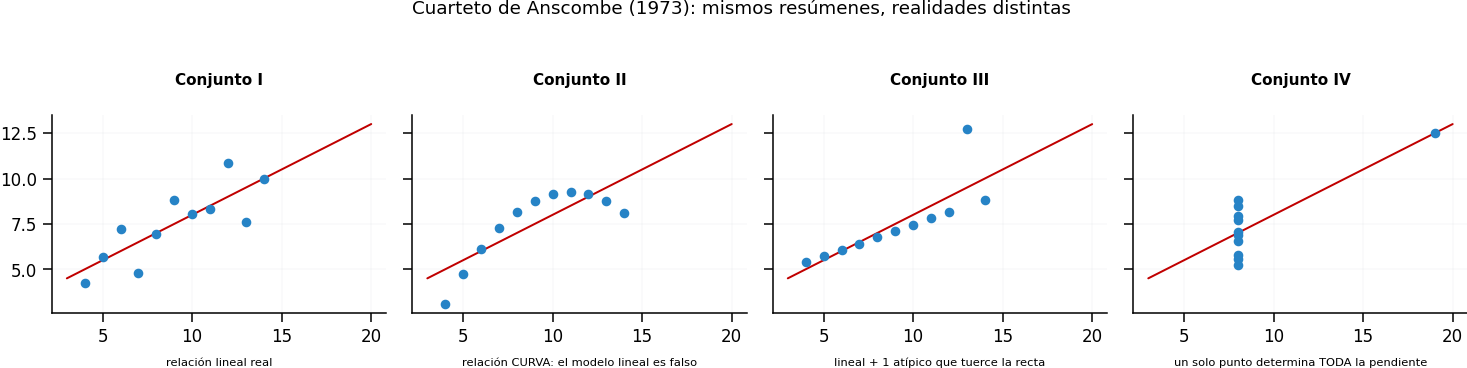

,media x,media y,var y,pendiente,r
Conjunto,,,,,
I,9.0,7.501,4.127,0.5,0.816
II,9.0,7.501,4.128,0.5,0.816
III,9.0,7.500,4.123,0.5,0.816
IV,9.0,7.501,4.123,0.5,0.817


In [9]:
ans = {
 "I":   ([10,8,13,9,11,14,6,4,12,7,5], [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]),
 "II":  ([10,8,13,9,11,14,6,4,12,7,5], [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]),
 "III": ([10,8,13,9,11,14,6,4,12,7,5], [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]),
 "IV":  ([8,8,8,8,8,8,8,19,8,8,8],     [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]),
}
lect = {"I": "relación lineal real", "II": "relación CURVA: el modelo lineal es falso",
        "III": "lineal + 1 atípico que tuerce la recta",
        "IV": "un solo punto determina TODA la pendiente"}

fig, ax = plt.subplots(1, 4, figsize=(13.5, 3.3), sharex=True, sharey=True)
res = []
for a, (k, (xs, ys)) in zip(ax, ans.items()):
    xs, ys = np.array(xs, float), np.array(ys, float)
    b, i0, r, _, _ = stats.linregress(xs, ys)
    xr = np.linspace(3, 20, 10)
    a.scatter(xs, ys, color=C["exp"], zorder=3, s=28)
    a.plot(xr, i0 + b * xr, color=C["bad"], lw=1.3)
    a.set_title(f"Conjunto {k}", fontsize=10)
    a.set_xlabel(lect[k], fontsize=7.5)
    res.append({"Conjunto": k, "media x": xs.mean(), "media y": ys.mean(),
                "var y": ys.var(ddof=1), "pendiente": b, "r": r})
fig.suptitle("Cuarteto de Anscombe (1973): mismos resúmenes, realidades distintas", y=1.06)
fig.tight_layout(); plt.show()

display(pd.DataFrame(res).set_index("Conjunto").round(3))

## 2.4 Cuando la media y la varianza sencillamente **no existen**

No es una curiosidad académica. En distribuciones de cola pesada la integral que define el
momento diverge, y entonces:

- **Cauchy** — $E[T]$ no existe. La media muestral **no converge**: tiene la misma distribución
  que una sola observación, sin importar cuántos datos acumule.
- **Pareto con $1<\alpha\le 2$** — la media **sí** existe y la media muestral converge, pero
  la varianza es infinita. La convergencia es lenta y a saltos, y **todo intervalo de confianza
  basado en el teorema central del límite clásico es inválido**: el punto estimado es legítimo,
  la incertidumbre reportada no.

Costos de mantenimiento, duración de paradas no programadas y pérdidas por indisponibilidad
exhiben con frecuencia colas de este tipo. La señal de alarma es visual: si la media acumulada
sigue dando saltos cuando ya lleva miles de observaciones, **el promedio no es un resumen
legítimo** y debe reportar percentiles.

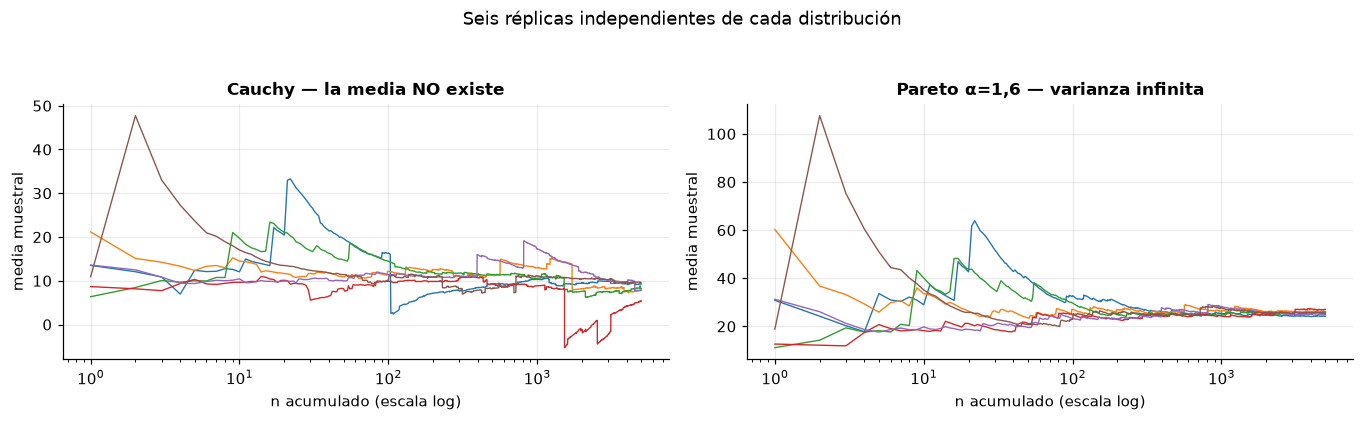

Contraste — Weibull bien portada, media acumulada en n=5000: 88.53 h (teórica 88.56 h)

Lectura precisa de la gráfica:
  Cauchy  -> la media muestral NO converge; el promedio carece de sentido.
  Pareto  -> la media SÍ converge (α>1), pero a saltos: cada observación extrema
             reubica el promedio. La varianza infinita invalida los IC usuales.

Regla: si la media acumulada no se aplana con suavidad, reporte mediana y percentiles.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))
casos = [(stats.cauchy(loc=10, scale=2),   "Cauchy — la media NO existe"),
         (stats.pareto(1.6, scale=10),     "Pareto α=1,6 — varianza infinita")]
for a, (dist, nom) in zip(ax, casos):
    for k in range(6):
        s = dist.rvs(5000, random_state=np.random.default_rng(100 + k))
        a.plot(np.arange(1, 5001), np.cumsum(s) / np.arange(1, 5001), lw=.9)
    a.set_xscale("log"); a.set_xlabel("n acumulado (escala log)")
    a.set_ylabel("media muestral"); a.set_title(nom)

fig.suptitle("Seis réplicas independientes de cada distribución", y=1.05)
fig.tight_layout(); plt.show()

w = stats.weibull_min(2.2, scale=100).rvs(5000, random_state=RNG)
print(f"Contraste — Weibull bien portada, media acumulada en n=5000: "
      f"{np.cumsum(w)[-1]/5000:.2f} h (teórica {stats.weibull_min(2.2, scale=100).mean():.2f} h)")
print("\nLectura precisa de la gráfica:")
print("  Cauchy  -> la media muestral NO converge; el promedio carece de sentido.")
print("  Pareto  -> la media SÍ converge (α>1), pero a saltos: cada observación extrema")
print("             reubica el promedio. La varianza infinita invalida los IC usuales.")
print("\nRegla: si la media acumulada no se aplana con suavidad, reporte mediana y percentiles.")

### 2.5 Qué reportar, en la práctica

| Situación | Reporte | Por qué |
|---|---|---|
| Presupuestar horas-hombre totales | **Media** × número de eventos | La suma es lo que importa; la media es el estimador natural del total |
| Describir una intervención típica | **Mediana** + rango intercuartílico | Robusta ante la parada excepcional |
| Definir un intervalo de reemplazo | **Percentil bajo** (B10, B5) | La media deja fallar a la mayoría antes |
| Dimensionar repuestos o riesgo | **Percentil alto** (P90, P95) | La decisión vive en la cola, no en el centro |
| Comparar dos equipos | **Frecuencia normalizada + IC** | Un punto sin incertidumbre no es comparable |

Y en todos los casos: **$n$, unidad y ventana de observación**. Un promedio sin esos tres
datos no es auditable.

---
# Parte 3 · Censura: el corazón del análisis de datos de vida

## 3.1 Qué es la censura y por qué no es un dato faltante

Una observación está **censurada** cuando sabemos algo sobre el tiempo de falla, pero no su
valor exacto. Es el caso normal, no la excepción: al cerrar un período de análisis, la mayoría
de los equipos **todavía no ha fallado**.

La distinción crítica: **censura ≠ dato faltante**. Una unidad censurada a las 45 horas aporta
la información positiva "$T > 45$ h". Eso restringe la distribución y debe entrar en la
estimación. Kaplan señaló el punto con precisión: las unidades censuradas no pueden
simplemente ignorarse, porque tienden a ser más longevas que el promedio
([Kaplan, en Garfield, 1983](https://garfield.library.upenn.edu/classics1983/A1983QS51100001.pdf)).

### Tipos

| Tipo | Qué se sabe | Origen típico |
|---|---|---|
| **Derecha, tipo I** | $T > C$, con $C$ fijo | Se corta el estudio en una fecha; $r$ es aleatorio |
| **Derecha, tipo II** | $T > t_{(r)}$ | Se detiene al acumular $r$ fallas; el tiempo es aleatorio |
| **Derecha, aleatoria** | $T > C_i$, $C_i$ variable | Entradas escalonadas, retiros por otras causas |
| **Izquierda** | $T < C$ | La falla ya había ocurrido en la primera inspección |
| **Intervalo** | $a < T \le b$ | Inspección periódica: solo se sabe entre qué rondas falló |

La censura por intervalo es la más común en inspección y la peor tratada: se resuelve con el
estimador de [Turnbull (1976)](https://doi.org/10.1111/j.2517-6161.1976.tb01597.x), que
generaliza Kaplan–Meier.

**Truncamiento es distinto.** Bajo censura la unidad está en la muestra con información
parcial; bajo truncamiento **nunca entró** (por ejemplo, equipos retirados antes de que
empezara el registro). Confundirlos genera sesgo de supervivencia.

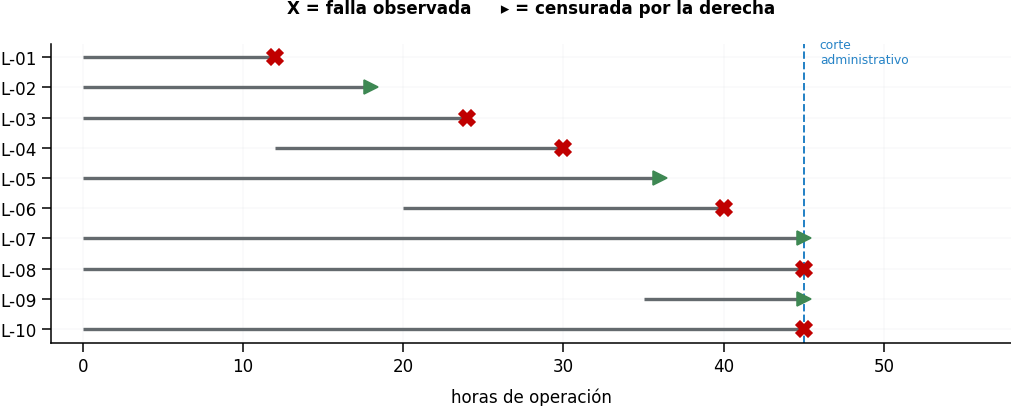

n = 10 | fallas = 6 | censuradas = 4

L-04, L-06 y L-09 entraron tarde: su reloj de edad empieza en su instalación,
no en el inicio del calendario. Mezclar ambos orígenes es un error frecuente.


In [11]:
datos = pd.DataFrame({
    "unidad":  [f"L-{i:02d}" for i in range(1, 11)],
    "entrada": [0, 0, 0, 12, 0, 20, 0, 0, 35, 0],
    "salida":  [12, 18, 24, 30, 36, 40, 45, 45, 45, 45],
    "evento":  [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
})

fig, ax = plt.subplots(figsize=(9.5, 4))
for i, r in datos.iterrows():
    ax.hlines(i, r.entrada, r.salida, color=C["ref"], lw=2.2)
    if r.evento:
        ax.plot(r.salida, i, "X", color=C["bad"], ms=11, zorder=3)
    else:
        ax.plot(r.salida, i, ">", color=C["log"], ms=9, zorder=3)
ax.axvline(45, ls="--", color=C["exp"], lw=1.3)
ax.text(46, 0.2, "corte\nadministrativo", color=C["exp"], fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(datos.unidad)
ax.set_xlabel("horas de operación"); ax.set_xlim(-2, 58); ax.invert_yaxis()
ax.set_title("X = falla observada     ▸ = censurada por la derecha")
fig.tight_layout(); plt.show()

print(f"n = {len(datos)} | fallas = {datos.evento.sum()} | "
      f"censuradas = {(1-datos.evento).sum()}")
print("\nL-04, L-06 y L-09 entraron tarde: su reloj de edad empieza en su instalación,")
print("no en el inicio del calendario. Mezclar ambos orígenes es un error frecuente.")

## 3.2 El experimento decisivo: tres formas de tratar la censura

Simulamos 60 unidades con vida **Weibull($\beta=2{,}2$; $\eta=100$ h)** —parámetros que
conocemos— y cortamos la observación a las 80 h. Comparamos:

- **A. Verosimilitud con censura (correcto).** Cada observación aporta según lo que se sabe:
  $$\mathcal{L}=\prod_{i=1}^{n} f(t_i)^{\delta_i}\,R(t_i)^{1-\delta_i}$$
  con $\delta_i=1$ si falló. La unidad censurada contribuye $R(t_i)=P(T>t_i)$.

- **B. Borrar las censuradas.** Se analizan solo las que fallaron. Como las fallas observadas
  son, por construcción, las más tempranas, esto **subestima gravemente la vida**.

- **C. Tratarlas como fallas.** Se registra el tiempo de corte como si fuera una falla. También
  subestima, porque asigna una falla a un tiempo en que el equipo seguía sano.

In [12]:
BETA_V, ETA_V, CORTE = 2.2, 100.0, 80.0

def nll_weibull(p, t, d):
    # Log-verosimilitud NEGATIVA de Weibull con censura por la derecha
    b, e = p
    if b <= 0 or e <= 0:
        return 1e12
    z = (t / e) ** b
    #   fallas (d=1): log f(t)   |   censuradas (d=0): log R(t) = -z
    return -(d * (np.log(b / e) + (b - 1) * np.log(t / e)) - z).sum()

def ajusta(t, d):
    r = optimize.minimize(nll_weibull, [1.5, np.mean(t)], args=(t, d), method="Nelder-Mead")
    return r.x

vidas = stats.weibull_min.rvs(BETA_V, scale=ETA_V, size=60,
                              random_state=np.random.default_rng(7))
t_obs = np.minimum(vidas, CORTE)
delta = (vidas <= CORTE).astype(int)
print(f"n = 60 | fallas observadas = {delta.sum()} | censuradas = {(1-delta).sum()}")

b_ok,   e_ok   = ajusta(t_obs, delta)                        # A
b_del,  e_del  = ajusta(t_obs[delta == 1], delta[delta == 1])  # B
b_mal,  e_mal  = ajusta(t_obs, np.ones_like(delta))          # C
b_full, e_full = ajusta(vidas, np.ones(60))                  # oráculo

comp = pd.DataFrame({
    "β":     [BETA_V, b_full, b_ok, b_del, b_mal],
    "η (h)": [ETA_V,  e_full, e_ok, e_del, e_mal],
}, index=["VERDAD (parámetros de simulación)",
          "Oráculo: vidas completas (no observable)",
          "A · MLE con censura  ✔",
          "B · Borrar las censuradas  ✘",
          "C · Censuradas como fallas  ✘"])
comp["MTTF (h)"] = [stats.weibull_min(b, scale=e).mean()     for b, e in zip(comp["β"], comp["η (h)"])]
comp["B10 (h)"]  = [stats.weibull_min(b, scale=e).ppf(.10)   for b, e in zip(comp["β"], comp["η (h)"])]
display(comp.round(2))

n = 60 | fallas observadas = 26 | censuradas = 34


,β,η (h),MTTF (h),B10 (h)
VERDAD (parámetros de simulación),2.20,100.00,88.56,35.96
Oráculo: vidas completas (no observable),2.05,98.07,86.88,32.72
A · MLE con censura ✔,1.79,109.90,97.75,31.37
B · Borrar las censuradas ✘,2.67,54.47,48.42,23.44
C · Censuradas como fallas ✘,4.13,72.78,66.09,42.21


Una sola muestra puede engañar por azar. Repetimos el experimento **300 veces** para separar
el sesgo sistemático del ruido muestral.

In [13]:
def replicas(nrep=300, n=60, corte=CORTE, seed=99):
    g = np.random.default_rng(seed)
    out = []
    for _ in range(nrep):
        v  = stats.weibull_min.rvs(BETA_V, scale=ETA_V, size=n, random_state=g)
        tt = np.minimum(v, corte); dd = (v <= corte).astype(int)
        if dd.sum() < 3:
            continue
        a = ajusta(tt, dd)
        b = ajusta(tt[dd == 1], dd[dd == 1])
        c = ajusta(tt, np.ones(n))
        out.append([stats.weibull_min(a[0], scale=a[1]).mean(),
                    stats.weibull_min(b[0], scale=b[1]).mean(),
                    stats.weibull_min(c[0], scale=c[1]).mean()])
    return np.array(out)

R = replicas()
verdad = stats.weibull_min(BETA_V, scale=ETA_V).mean()
resumen = pd.DataFrame({
    "MTTF estimado medio (h)": R.mean(0),
    "sesgo (h)":               R.mean(0) - verdad,
    "error sistemático (%)":  100 * (R.mean(0) - verdad) / verdad,
}, index=["A · MLE con censura  ✔", "B · Borrar censuradas  ✘",
          "C · Censuradas como fallas  ✘"]).round(2)
display(resumen)
print(f"MTTF verdadero = {verdad:.2f} h  (300 réplicas)")
print("\nA es prácticamente insesgado. B y C se equivocan SIEMPRE en la misma dirección:")
print("más datos NO los corrigen, porque el error está en la regla, no en el tamaño muestral.")

,MTTF estimado medio (h),sesgo (h),error sistemático (%)
A · MLE con censura ✔,90.63,2.07,2.34
B · Borrar censuradas ✘,51.77,-36.80,-41.55
C · Censuradas como fallas ✘,67.39,-21.17,-23.90


MTTF verdadero = 88.56 h  (300 réplicas)

A es prácticamente insesgado. B y C se equivocan SIEMPRE en la misma dirección:
más datos NO los corrigen, porque el error está en la regla, no en el tamaño muestral.


Este resultado enlaza directamente con la distinción entre sesgo y precisión: **B y C no son
imprecisos, son sesgados**. Acumular más unidades produciría un número cada vez más estable
alrededor de un valor equivocado. Y el error apunta hacia el lado peligroso: subestimar la vida
lleva a reemplazar antes de tiempo y a gastar de más.

## 3.3 Kaplan–Meier: estimar $R(t)$ sin suponer ninguna distribución

El estimador producto-límite de [Kaplan y Meier (1958)](https://doi.org/10.1080/01621459.1958.10501452)
—uno de los artículos más citados de la estadística— construye la confiabilidad **sin postular
modelo alguno**:

$$\hat{R}(t)=\prod_{t_i \le t}\left(1-\frac{d_i}{n_i}\right)$$

donde $d_i$ son las fallas en $t_i$ y $n_i$ los equipos **en riesgo** justo antes de $t_i$. La
censura no entra en el numerador: simplemente **reduce $n_i$** de ahí en adelante. Esa es toda
la idea, y es la razón por la que la información parcial se aprovecha correctamente.

La incertidumbre se cuantifica con la fórmula de Greenwood (1926):

$$\widehat{\operatorname{Var}}[\hat R(t)] = \hat R(t)^2 \sum_{t_i\le t}\frac{d_i}{n_i\,(n_i-d_i)}$$

Lo implementamos a mano para que cada paso quede a la vista.

,t,n en riesgo,fallas d_i,R(t),IC95 inf,IC95 sup
0,7.8854,60,1,0.9833,0.9509,1.0000
1,9.2216,59,1,0.9667,0.9212,1.0000
2,13.3246,58,1,0.9500,0.8949,1.0000
3,22.1609,57,1,0.9333,0.8702,0.9965
4,24.4088,56,1,0.9167,0.8467,0.9866
5,28.0630,55,1,0.9000,0.8241,0.9759


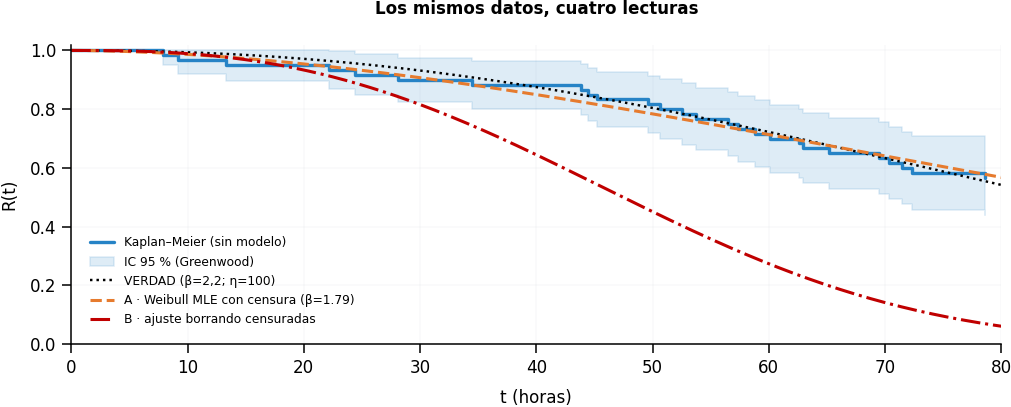

Note el ancho del intervalo de Greenwood: crece a medida que quedan menos equipos
en riesgo. La curva NO se vuelve más confiable en la cola; se vuelve menos.


In [14]:
def kaplan_meier(t, d):
    # Estimador producto-limite + varianza de Greenwood (implementacion explicita)
    tiempos = np.sort(np.unique(t[d == 1]))
    S, V, filas = 1.0, 0.0, []
    for ti in tiempos:
        n_riesgo = (t >= ti).sum()                 # censurados SALEN del conjunto en riesgo
        d_i      = ((t == ti) & (d == 1)).sum()
        S *= (1 - d_i / n_riesgo)
        V += d_i / (n_riesgo * (n_riesgo - d_i)) if n_riesgo > d_i else 0.0
        se = S * np.sqrt(V)                        # Greenwood
        filas.append((ti, n_riesgo, d_i, S, max(S - 1.96*se, 0), min(S + 1.96*se, 1)))
    return pd.DataFrame(filas, columns=["t", "n en riesgo", "fallas d_i",
                                        "R(t)", "IC95 inf", "IC95 sup"])

km = kaplan_meier(t_obs, delta)
display(km.head(6).round(4))

fig, ax = plt.subplots(figsize=(9.5, 4))
xs, ys = np.r_[0, km.t.values], np.r_[1, km["R(t)"].values]
ax.step(xs, ys, where="post", color=C["exp"], lw=2.2, label="Kaplan–Meier (sin modelo)")
ax.fill_between(xs, np.r_[1, km["IC95 inf"].values], np.r_[1, km["IC95 sup"].values],
                step="post", alpha=.15, color=C["exp"], label="IC 95 % (Greenwood)")
tt = np.linspace(0, 80, 300)
ax.plot(tt, stats.weibull_min.sf(tt, BETA_V, scale=ETA_V), color="k", ls=":", lw=1.6,
        label="VERDAD (β=2,2; η=100)")
ax.plot(tt, stats.weibull_min.sf(tt, b_ok, scale=e_ok), color=C["wei"], ls="--",
        label=f"A · Weibull MLE con censura (β={b_ok:.2f})")
ax.plot(tt, stats.weibull_min.sf(tt, b_del, scale=e_del), color=C["bad"], ls="-.",
        label="B · ajuste borrando censuradas")
ax.set_xlabel("t (horas)"); ax.set_ylabel("R(t)"); ax.set_ylim(0, 1.02); ax.set_xlim(0, 80)
ax.legend(fontsize=8, loc="lower left"); ax.set_title("Los mismos datos, cuatro lecturas")
fig.tight_layout(); plt.show()

print("Note el ancho del intervalo de Greenwood: crece a medida que quedan menos equipos")
print("en riesgo. La curva NO se vuelve más confiable en la cola; se vuelve menos.")

**Limitaciones que conviene declarar.** Kaplan–Meier no extrapola: más allá del último tiempo
observado no dice nada. Si la observación termina en una censura, la curva queda "colgada" y no
llega a cero, por lo que el MTTF calculado bajo el área de la curva queda subestimado. Y con
pocos equipos en riesgo los escalones finales son muy inestables.

## 3.4 El supuesto que lo sostiene todo: censura no informativa

Kaplan y Meier son explícitos en el resumen de su artículo: se supone que el tiempo de vida es
independiente del tiempo potencial de pérdida, y advierten que en la práctica ese supuesto
**merece un escrutinio cuidadoso**
([Kaplan y Meier, 1958, p. 457](https://doi.org/10.1080/01621459.1958.10501452)).

Es el supuesto más frágil y el menos verificable del análisis de vida, porque **no se puede
comprobar con los datos observados**. Se viola de forma rutinaria en mantenimiento: si un
técnico retira un equipo porque detectó vibración anómala —es decir, *porque estaba a punto de
fallar*—, esa censura está correlacionada con la vida y el estimador se vuelve optimista.

Lo simulamos: la mitad de las unidades se inspecciona y se retira poco antes de su falla real.

In [15]:
g = np.random.default_rng(11)
n = 500
vid = stats.weibull_min.rvs(BETA_V, scale=ETA_V, size=n, random_state=g)

inspeccionada = g.random(n) < 0.50                      # 50 % bajo monitoreo de condición
retiro = np.where(inspeccionada,
                  np.maximum(vid - g.uniform(2, 15, n), 0.5),   # se retira ANTES de fallar
                  np.inf)
ADMIN = 150.0
t_inf = np.minimum(np.minimum(vid, retiro), ADMIN)
d_inf = ((vid <= retiro) & (vid <= ADMIN)).astype(int)

b_i, e_i = ajusta(t_inf, d_inf)
m_i = stats.weibull_min(b_i, scale=e_i)
m_v = stats.weibull_min(BETA_V, scale=ETA_V)

display(pd.DataFrame({
    "β": [BETA_V, b_i], "η (h)": [ETA_V, e_i],
    "MTTF (h)": [m_v.mean(), m_i.mean()], "B10 (h)": [m_v.ppf(.1), m_i.ppf(.1)],
}, index=["VERDAD", "Estimado con censura informativa"]).round(2))

print(f"\nSobrestimación del MTTF: {100*(m_i.mean()-m_v.mean())/m_v.mean():+.1f} %")
print(f"Sobrestimación del B10 : {100*(m_i.ppf(.1)-m_v.ppf(.1))/m_v.ppf(.1):+.1f} %")
print("\nEl método es correcto y el cálculo es correcto. El SUPUESTO es falso,")
print("y ninguna prueba estadística sobre estos datos lo detectaría.")
print("Solo lo detecta preguntar POR QUÉ se retiró cada unidad.")

,β,η (h),MTTF (h),B10 (h)
VERDAD,2.20,100.0,88.56,35.96
Estimado con censura informativa,2.25,129.5,114.70,47.64



Sobrestimación del MTTF: +29.5 %
Sobrestimación del B10 : +32.5 %

El método es correcto y el cálculo es correcto. El SUPUESTO es falso,
y ninguna prueba estadística sobre estos datos lo detectaría.
Solo lo detecta preguntar POR QUÉ se retiró cada unidad.


Esta es la razón por la que en un análisis de vida hay que registrar el **motivo de salida** de
cada unidad, no solo su tiempo. Un retiro por cierre de período y un retiro por deterioro
incipiente producen el mismo dato y tienen consecuencias estadísticas opuestas.

---
# Parte 4 · Los datos no siguen modelos; los modelos siguen a los datos

## 4.1 La inversión conceptual

Decir "estos datos siguen una Weibull" invierte la relación real. Una Weibull es un objeto
matemático; un conjunto de tiempos de falla es un registro de hechos físicos. Lo correcto es:
*"propongo una Weibull como aproximación, y aquí está la evidencia de qué tan bien funciona y
dónde se rompe"*.

Box (1976) desarrolló este punto en su conferencia memorial en honor a Fisher: el progreso
científico ocurre por iteración entre teoría y práctica, y como todos los modelos son falsos,
el científico no obtiene uno "correcto" por elaboración excesiva, sino que debe buscar una
descripción económica y estar alerta a lo que está **importantemente** mal
([Box, 1976, p. 792](https://doi.org/10.1080/01621459.1976.10480949)). La formulación
completa del aforismo aparece después en Box y Draper (1987, p. 424).

Tres consecuencias operativas:

1. **Ningún modelo es "el verdadero".** La pregunta útil no es cuál es correcto, sino cuál es
   adecuado *para esta decisión*.
2. **La bondad de ajuste no valida la extrapolación.** Un modelo puede describir bien la nube
   de datos y errar por órdenes de magnitud fuera de ella.
3. **El criterio de adecuación depende de la pregunta.** El modelo que mejor estima el MTTF
   puede ser pésimo para estimar el B1.

## 4.2 Demostración: cuatro modelos que "ajustan bien" y no coinciden donde importa

In [16]:
g = np.random.default_rng(4)
obs = stats.weibull_min.rvs(1.8, scale=90, size=25, random_state=g)
print(f"n = {len(obs)} | rango observado: {obs.min():.1f} – {obs.max():.1f} h")

candidatos = {"Weibull": stats.weibull_min, "Lognormal": stats.lognorm, "Gamma": stats.gamma}
filas, ajustados = [], {}
for nom, D in candidatos.items():
    par = D.fit(obs, floc=0)
    d   = D(*par)
    ll  = D.logpdf(obs, *par).sum()
    k   = len(par) - 1
    filas.append({
        "Modelo": nom, "log-verosim.": ll, "AIC": 2*k - 2*ll,
        "KS p-valor": stats.kstest(obs, D.name, par).pvalue,
        "MTTF (h)": d.mean(), "B10 (h)": d.ppf(.10),
        "B1 (h)": d.ppf(.01), "R(300 h)": d.sf(300),
    })
    ajustados[nom] = d
res = pd.DataFrame(filas).set_index("Modelo")
display(res.round(4))

b1 = res["B1 (h)"]; r300 = res["R(300 h)"]
print(f"\nDENTRO de los datos   -> MTTF varía  {res['MTTF (h)'].max()/res['MTTF (h)'].min():.2f}×")
print(f"                         B10 varía   {res['B10 (h)'].max()/res['B10 (h)'].min():.2f}×")
print(f"FUERA de los datos    -> B1 varía    {b1.max()/b1.min():.2f}×")
print(f"                         R(300 h) varía {r300.max()/r300.min():.0f}×   <-- !!")
print("\nLos tres modelos pasan la prueba KS con p > 0,96. Ninguna prueba los distingue.")

n = 25 | rango observado: 22.8 – 198.3 h


,log-verosim.,AIC,KS p-valor,MTTF (h),B10 (h),B1 (h),R(300 h)
Modelo,,,,,,,
Weibull,-132.3537,268.7074,0.9667,101.4088,39.7459,13.1663,0.0004
Lognormal,-133.5886,271.1773,0.9664,103.1389,41.3552,22.5308,0.0167
Gamma,-132.6569,269.3138,0.9789,101.1412,40.9695,17.9333,0.0041



DENTRO de los datos   -> MTTF varía  1.02×
                         B10 varía   1.04×
FUERA de los datos    -> B1 varía    1.71×
                         R(300 h) varía 39×   <-- !!

Los tres modelos pasan la prueba KS con p > 0,96. Ninguna prueba los distingue.


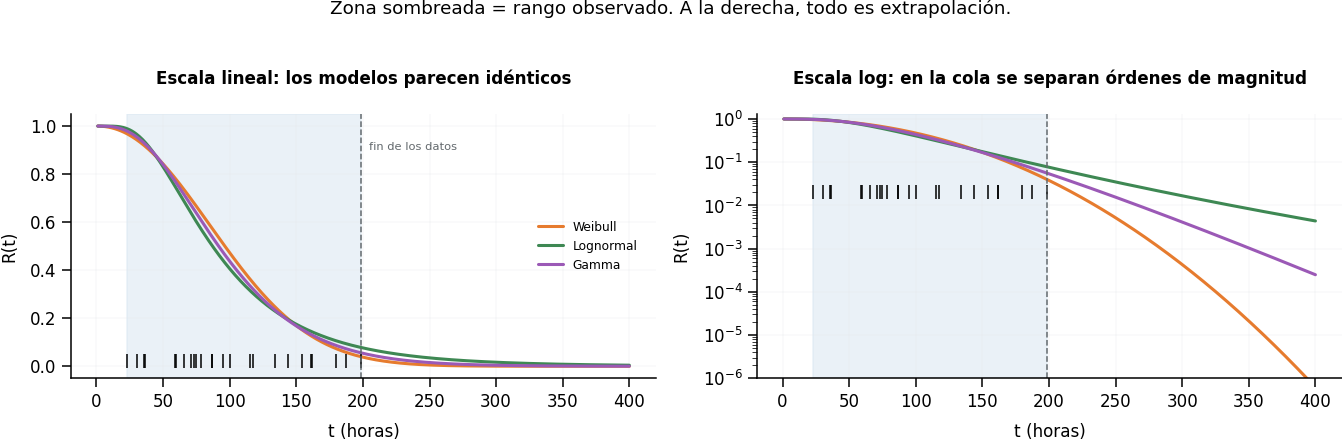

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
tt = np.linspace(1, 400, 500)
cols = [C["wei"], C["log"], C["gam"]]

for (nom, d), c in zip(ajustados.items(), cols):
    ax[0].plot(tt, d.sf(tt), color=c, label=nom)
    ax[1].semilogy(tt, d.sf(tt), color=c, label=nom)
for a in (ax[0], ax[1]):
    a.axvspan(obs.min(), obs.max(), color="#D9E6F2", alpha=.55, zorder=0)
    a.plot(obs, np.full_like(obs, .02), "|", color="k", ms=9)
    a.set_xlabel("t (horas)")
    a.axvline(obs.max(), ls="--", color=C["ref"], lw=1)
ax[0].set_title("Escala lineal: los modelos parecen idénticos")
ax[1].set_title("Escala log: en la cola se separan órdenes de magnitud")
ax[1].set_ylim(1e-6, 1.3); ax[0].legend(fontsize=8, loc="center right")
ax[0].set_ylabel("R(t)"); ax[1].set_ylabel("R(t)")
ax[0].text(obs.max() + 6, .90, "fin de los datos", fontsize=7.5, color=C["ref"])
fig.suptitle("Zona sombreada = rango observado. A la derecha, todo es extrapolación.", y=1.04)
fig.tight_layout(); plt.show()

Este es el hallazgo central de la parte 4. Los tres modelos son **indistinguibles
estadísticamente** con estos datos (KS con $p>0{,}96$, AIC dentro de 2,5 unidades), coinciden
en el MTTF y el B10 dentro de un 4 %, y difieren en $R(300\text{ h})$ por un factor de más de
40. La diferencia no proviene de los datos —que no dicen nada más allá de su rango—, sino de
la **forma funcional que impusimos** al elegir el modelo.

Regla operativa: **la incertidumbre real de una extrapolación incluye la incertidumbre sobre
el modelo**, que ningún intervalo de confianza calculado *dentro* de un modelo captura.

## 4.3 Con $n$ pequeño, el ajuste inventa mecanismos que no existen

Un riesgo más sutil y más costoso: generamos datos **exactamente exponenciales** ($\beta=1$ por
construcción: no hay desgaste, no hay mortalidad infantil) y ajustamos una Weibull. Si el
$\hat\beta$ estimado se aleja de 1, un analista concluirá que existe un mecanismo de desgaste
—y recomendará reemplazo preventivo por edad— sobre un fenómeno puramente aleatorio.

,β mediana,β P5,β P95,"P(concluir DESGASTE: β>1,3)","P(concluir INFANTIL: β<0,8)"
n,,,,,
5,1.217,0.679,2.726,0.430,0.112
10,1.098,0.716,1.736,0.295,0.125
20,1.057,0.794,1.472,0.170,0.053
30,1.032,0.826,1.321,0.053,0.025
100,1.006,0.888,1.152,0.002,0.000
500,1.007,0.947,1.061,0.000,0.000


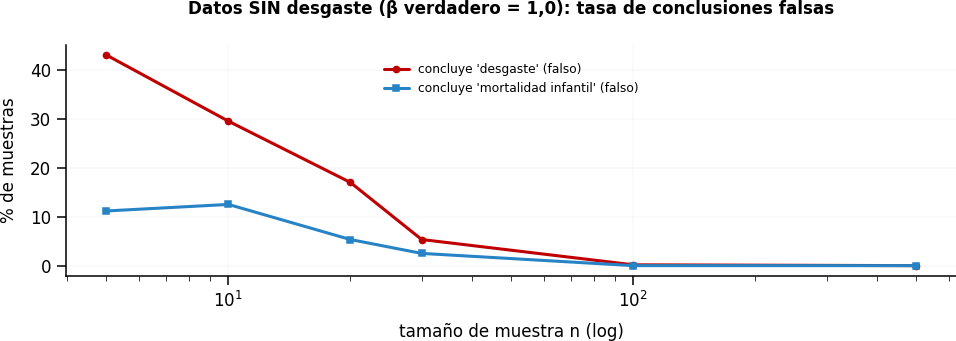

VERDAD: los datos son exponenciales, β = 1,00 exacto. No hay desgaste.

Con n = 5, el 43 % de las muestras produce β > 1,3 y sugiere desgaste inexistente.
Con n = 30 el error baja a ~7 %; con n ≥ 100 prácticamente desaparece.

El modelo no descubrió un mecanismo: reprodujo el ruido de una muestra pequeña.


In [18]:
g = np.random.default_rng(3)
filas = []
for n in (5, 10, 20, 30, 100, 500):
    bs = np.array([ajusta(g.exponential(100, n), np.ones(n))[0] for _ in range(600)])
    filas.append({
        "n": n, "β mediana": np.median(bs),
        "β P5": np.percentile(bs, 5), "β P95": np.percentile(bs, 95),
        "P(concluir DESGASTE: β>1,3)": np.mean(bs > 1.3),
        "P(concluir INFANTIL: β<0,8)": np.mean(bs < 0.8),
    })
d = pd.DataFrame(filas).set_index("n")
display(d.round(3))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(d.index, d["P(concluir DESGASTE: β>1,3)"] * 100, "o-", color=C["bad"],
        label="concluye 'desgaste' (falso)")
ax.plot(d.index, d["P(concluir INFANTIL: β<0,8)"] * 100, "s-", color=C["exp"],
        label="concluye 'mortalidad infantil' (falso)")
ax.set_xscale("log"); ax.set_xlabel("tamaño de muestra n (log)")
ax.set_ylabel("% de muestras"); ax.legend(fontsize=8)
ax.set_title("Datos SIN desgaste (β verdadero = 1,0): tasa de conclusiones falsas")
fig.tight_layout(); plt.show()

print("VERDAD: los datos son exponenciales, β = 1,00 exacto. No hay desgaste.")
print("\nCon n = 5, el 43 % de las muestras produce β > 1,3 y sugiere desgaste inexistente.")
print("Con n = 30 el error baja a ~7 %; con n ≥ 100 prácticamente desaparece.")
print("\nEl modelo no descubrió un mecanismo: reprodujo el ruido de una muestra pequeña.")

## 4.4 Lista de verificación antes de creerle a un modelo ajustado

| # | Pregunta | Si la respuesta es "no"… |
|---|---|---|
| 1 | ¿La población es homogénea en función, servicio y carga? | Segmente; un $\beta$ mezclado no describe a nadie |
| 2 | ¿Las unidades censuradas están incluidas en la verosimilitud? | El resultado está sesgado, no solo es impreciso |
| 3 | ¿Conozco el **motivo** de cada censura? | La censura puede ser informativa y usted no lo sabrá |
| 4 | ¿El origen del reloj es el mismo para todas las unidades? | Está mezclando edades incomparables |
| 5 | ¿Miré la gráfica —KM, papel probabilístico, residuos—? | Anscombe (1973): los resúmenes no identifican los datos |
| 6 | ¿Comparé al menos dos familias de modelos? | No sabe cuánta de su conclusión viene del modelo |
| 7 | ¿Mi decisión está **dentro** del rango observado? | Está extrapolando; declare la incertidumbre de modelo |
| 8 | ¿Reporté $n$, unidad, ventana e intervalo de confianza? | El número no es auditable ni reproducible |
| 9 | ¿El $\beta$ estimado tiene un mecanismo físico que lo respalde? | Puede ser ruido muestral (ver 4.3) |
| 10 | ¿Un colega podría reconstruir el resultado con mi documentación? | Aún no terminó el análisis |

## 4.5 Cierre

El orden correcto del razonamiento es:

**1. Pregunta de decisión** → **2. Diseño del dato** (¿qué reloj, qué población, qué criterio de
falla?) → **3. Descripción sin modelo** (Kaplan–Meier, percentiles, gráficas) → **4. Modelo
paramétrico si hace falta extrapolar** → **5. Declaración explícita de supuestos y límites**.

Invertir ese orden —elegir la distribución primero y buscar después datos que la sustenten— es
la forma más común y más cara de equivocarse en análisis de confiabilidad.

La Parte 3 mostró que un método incorrecto se equivoca **sistemáticamente**, y que más datos no
lo salvan. La Parte 4 mostró que un método correcto aplicado a pocos datos produce conclusiones
**que suenan físicas y son ruido**. Entre esos dos errores se juega la credibilidad técnica de
un análisis de vida.

---
## Referencias

Todas verificadas contra la fuente primaria o contra el registro del editor.

1. **Anscombe, F. J.** (1973). Graphs in statistical analysis. *The American Statistician,
   27*(1), 17–21. https://www.jstor.org/stable/2682899

2. **Box, G. E. P.** (1976). Science and statistics. *Journal of the American Statistical
   Association, 71*(356), 791–799. https://doi.org/10.1080/01621459.1976.10480949
   *(Conferencia memorial R. A. Fisher; el pasaje sobre modelos falsos está en la p. 792.)*

3. **Box, G. E. P., y Draper, N. R.** (1987). *Empirical model-building and response surfaces*
   (p. 424). Wiley. *(Formulación completa del aforismo.)*

4. **Greenwood, M.** (1926). The natural duration of cancer. *Reports on Public Health and
   Medical Subjects, No. 33*. His Majesty's Stationery Office. *(Origen de la fórmula de
   varianza usada en la sección 3.3.)*

5. **International Organization for Standardization.** (2016). *ISO 14224:2016 — Petroleum,
   petrochemical and natural gas industries: Collection and exchange of reliability and
   maintenance data for equipment* [ficha pública consultada].
   https://www.iso.org/standard/64076.html

6. **Kaplan, E. L., y Meier, P.** (1958). Nonparametric estimation from incomplete
   observations. *Journal of the American Statistical Association, 53*(282), 457–481.
   https://doi.org/10.1080/01621459.1958.10501452

7. **Lawless, J. F.** (2003). *Statistical models and methods for lifetime data* (2.ª ed.).
   Wiley.

8. **Meeker, W. Q., Escobar, L. A., y Pascual, F. G.** (2022). *Statistical methods for
   reliability data* (2.ª ed.). Wiley.

9. **National Institute of Standards and Technology.** (2012). *NIST/SEMATECH e-handbook of
   statistical methods*. https://doi.org/10.18434/M32189

10. **Nelson, W.** (1982). *Applied life data analysis*. Wiley.

11. **Turnbull, B. W.** (1976). The empirical distribution function with arbitrarily grouped,
    censored and truncated data. *Journal of the Royal Statistical Society, Series B, 38*(3),
    290–295. https://doi.org/10.1111/j.2517-6161.1976.tb01597.x

12. **Weibull, W.** (1951). A statistical distribution function of wide applicability. *Journal
    of Applied Mechanics, 18*(3), 293–297. https://doi.org/10.1115/1.4010337

---

### Alcance de la evidencia

Las fuentes anteriores respaldan los **métodos y definiciones** empleados. **No respaldan los
valores numéricos de los ejemplos**, que son simulaciones generadas en este cuaderno con
parámetros declarados y semilla fija. Ninguna cifra proviene de un activo, una flota o una
organización real. Cualquier aplicación a datos operativos exige validación de los criterios de
falla, del reloj de exposición y de la homogeneidad técnica de la población, con juicio de
ingeniería.